In [44]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "Machine learning is fun",
    "Deep learning powers AI",
    "Machine learning powers many applications"
]

In [46]:
def preprocess(text):
    stop = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w.isalpha() and w not in stop]

preprocessed = [preprocess(doc) for doc in documents]
print("Preprocessed tokens:")
for i, tokens in enumerate(preprocessed):
    print(f"  doc{i+1}: {tokens}")

Preprocessed tokens:
  doc1: ['machine', 'learning', 'fun']
  doc2: ['deep', 'learning', 'powers', 'ai']
  doc3: ['machine', 'learning', 'powers', 'many', 'applications']


In [47]:
def build_vocabulary(tokenized_docs):
    vocab = sorted(set(word for doc in tokenized_docs for word in doc))
    print("Vocabulary:", vocab)
    return vocab

vocab = build_vocabulary(preprocessed)

Vocabulary: ['ai', 'applications', 'deep', 'fun', 'learning', 'machine', 'many', 'powers']


In [48]:
def build_bow_matrix(tokenized_docs, vocab):
    rows = []
    for i, tokens in enumerate(tokenized_docs):
        row = {word: tokens.count(word) for word in vocab}
        rows.append(row)
    df = pd.DataFrame(rows, index=[f"doc{i+1}" for i in range(len(tokenized_docs))])
    return df

manual_bow = build_bow_matrix(preprocessed, vocab)
print("Manual BoW Matrix:")
print(manual_bow)

Manual BoW Matrix:
      ai  applications  deep  fun  learning  machine  many  powers
doc1   0             0     0    1         1        1     0       0
doc2   1             0     1    0         1        0     0       1
doc3   0             1     0    0         1        1     1       1


In [49]:
def sklearn_bow(documents):
    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(documents)
    df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(),index=[f"doc{i+1}" for i in range(len(documents))])
    return df

sklearn_bow_df = sklearn_bow(documents)
print("sklearn BoW Matrix:")
print(sklearn_bow_df)

sklearn BoW Matrix:
      ai  applications  deep  fun  learning  machine  powers
doc1   0             0     0    1         1        1       0
doc2   1             0     1    0         1        0       1
doc3   0             1     0    0         1        1       1


Analysis :

BOW ignores Word order as it stores only how many times each word appears, so two different docs can produce the exact vector 

2. As vocablury becomes large the matrix gets filled with mostly zeros, sparse matrix case 

3.sklearn BOW matrix has dropped 'many' considering it as stopword 

Question 2 — TF-IDF Representation

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def build_tfidf(documents):
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(documents)
    df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(),index=[f"doc{i+1}" for i in range(len(documents))])
    return df, vectorizer

tfidf_df, tfidf_vectorizer = build_tfidf(documents)
print("TF-IDF Matrix:")
print(tfidf_df.round(4))

TF-IDF Matrix:
          ai  applications    deep     fun  learning  machine  powers
doc1  0.0000        0.0000  0.0000  0.7203    0.4254   0.5478  0.0000
doc2  0.5845        0.0000  0.5845  0.0000    0.3452   0.0000  0.4445
doc3  0.0000        0.6317  0.0000  0.0000    0.3731   0.4805  0.4805


In [52]:
def top_tfidf_words(tfidf_df, n=3):
    for doc in tfidf_df.index:
        top = tfidf_df.loc[doc].nlargest(n)
        print(f"{doc} : {list(top.index)}")

print("Top 3 words per document:")
top_tfidf_words(tfidf_df)

Top 3 words per document:
doc1 : ['fun', 'machine', 'learning']
doc2 : ['ai', 'deep', 'powers']
doc3 : ['applications', 'machine', 'powers']


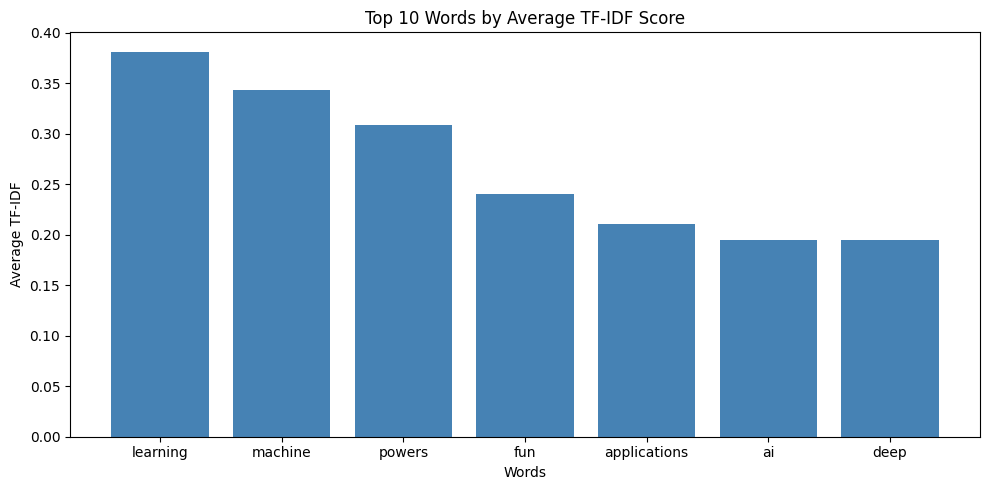

In [53]:
def plot_top_tfidf(tfidf_df, n=10):
    mean_scores = tfidf_df.mean(axis=0).nlargest(n)
    plt.figure(figsize=(10, 5))
    plt.bar(mean_scores.index, mean_scores.values, color='steelblue')
    plt.title(f"Top {n} Words by Average TF-IDF Score")
    plt.xlabel("Words")
    plt.ylabel("Average TF-IDF")
    plt.tight_layout()
    plt.show()

plot_top_tfidf(tfidf_df)

Analysis :

1. common words get low TF-IDF scores becuase the IDF becomes close to 0 
2.TF-IDF is better than BOW because BOW only counts frequency but TF-IDF gives word importance by both considering the frequency of the word and also its rarity across our corpus. 


Question 3 : TF-IDF Practical Application

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

corpus = [
    "Machine learning algorithms improve with more data",
    "Deep learning uses neural networks for image recognition",
    "Natural language processing helps computers understand text",
    "Python is a popular programming language for data science",
    "Reinforcement learning trains agents through rewards and penalties",
    "Computer vision enables machines to interpret visual information",
    "Data preprocessing is a crucial step in machine learning",
    "Transformers revolutionized natural language understanding",
    "Convolutional networks are widely used for image classification",
    "Feature engineering improves model performance significantly",
    "AI research is advancing rapidly with large language models",
    "Clustering algorithms group similar data points together",
    "Gradient descent optimizes neural network weights during training",
    "Recurrent networks are designed to handle sequential data",
    "Transfer learning reuses pretrained models on new tasks"
]

In [55]:
def build_search_index(corpus):
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(corpus)
    return vectorizer, X

search_vectorizer, corpus_matrix = build_search_index(corpus)

In [56]:
def search(query, vectorizer, corpus_matrix, corpus, top_n=3):
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, corpus_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_n]
    print(f"Query: '{query}'")
    print("Top results:")
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. [{similarities[idx]:.4f}] {corpus[idx]}")
    print()

search("machine learning models", search_vectorizer, corpus_matrix, corpus)
search("neural networks image classification", search_vectorizer, corpus_matrix, corpus)
search("natural language AI", search_vectorizer, corpus_matrix, corpus)

Query: 'machine learning models'
Top results:
  1. [0.4612] Machine learning algorithms improve with more data
  2. [0.3935] Data preprocessing is a crucial step in machine learning
  3. [0.3392] Transfer learning reuses pretrained models on new tasks

Query: 'neural networks image classification'
Top results:
  1. [0.5771] Convolutional networks are widely used for image classification
  2. [0.5089] Deep learning uses neural networks for image recognition
  3. [0.1646] Gradient descent optimizes neural network weights during training

Query: 'natural language AI'
Top results:
  1. [0.4037] Transformers revolutionized natural language understanding
  2. [0.3986] AI research is advancing rapidly with large language models
  3. [0.3329] Natural language processing helps computers understand text



1. Why is TF-IDF useful for search engines?

It ranks documents by the distinct words matching the query. For "neural networks image classification" the top result scored 0.5771 (convolutional networks) which is the most relevant

2. What limitation does TF-IDF have?

It only matches exact words. A query for "deep learning" would score 0 against a document that says "neural nets" even though they mean the same thing. There is no understanding of meaning, only character matching.



In [57]:
from gensim.models import Word2Vec

sentences = [
    ["machine", "learning", "is", "fun"],
    ["deep", "learning", "powers", "ai"],
    ["ai", "is", "the", "future"],
    ["machine", "learning", "and", "deep", "learning", "are", "related"],
    ["neural", "networks", "power", "deep", "learning"],
    ["ai", "applications", "are", "growing", "fast"]
]

In [58]:
def train_word2vec(sentences, vector_size=50, window=2, min_count=1, sg=0):
    model = Word2Vec(sentences, vector_size=vector_size, window=window,
                     min_count=min_count, sg=sg, seed=42)
    return model

model = train_word2vec(sentences)
print("Model trained. Vocabulary:", list(model.wv.index_to_key))

Model trained. Vocabulary: ['learning', 'ai', 'deep', 'are', 'is', 'machine', 'fast', 'growing', 'applications', 'power', 'networks', 'neural', 'related', 'and', 'future', 'the', 'powers', 'fun']


In [59]:
def show_similar_words(model, word, topn=5):
    similar = model.wv.most_similar(word, topn=topn)
    print(f"Words most similar to '{word}':")
    for w, score in similar:
        print(f"  {w}: {score:.4f}")

show_similar_words(model, "learning")
show_similar_words(model, "ai")

Words most similar to 'learning':
  powers: 0.2422
  networks: 0.1309
  fast: 0.0446
  deep: -0.0136
  power: -0.0188
Words most similar to 'ai':
  related: 0.3309
  are: 0.2051
  future: 0.2040
  the: 0.1631
  fun: 0.1367


In [60]:
def show_word_vector(model, word):
    vector = model.wv[word]
    print(f"Vector for '{word}' (size={len(vector)}):")
    print(vector)

show_word_vector(model, "ai")
show_word_vector(model, "learning")

Vector for 'ai' (size=50):
[ 1.04003511e-02 -1.22184409e-02 -5.44709293e-03 -1.32871722e-03
 -8.80186490e-05 -1.82509925e-02  1.86450116e-03 -1.38312252e-02
  9.73425526e-03  7.32445903e-03  1.69017091e-02  9.79229063e-03
 -5.33237960e-03  1.87058672e-02 -3.56737105e-03 -6.96634315e-03
  1.62245724e-02 -5.18252375e-03 -1.69510245e-02 -1.21870253e-03
  1.18299108e-02 -1.24200797e-02 -1.48560642e-03 -1.48040643e-02
  7.46235857e-03 -9.69215005e-04 -6.79363869e-03 -1.09275961e-02
  2.57899659e-03  6.79571507e-03  1.76172052e-02 -2.51347362e-03
 -1.35768186e-02  1.33068496e-02  5.19122509e-03  8.01235158e-03
 -1.61162131e-02 -7.50534516e-03  1.07156504e-02  1.32894488e-02
 -2.59417784e-03  1.21921441e-02  1.36710955e-02 -4.49957512e-03
  1.59255024e-02 -8.46940279e-03 -1.04164304e-02  7.30067445e-03
  5.47018135e-03 -1.44124366e-02]
Vector for 'learning' (size=50):
[-1.64282043e-02  1.09634027e-02  6.18363917e-03 -2.44947476e-03
 -2.66968948e-03  1.43404212e-02 -1.65650174e-02  7.89347943e

In [61]:
model_cbow = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=0, seed=42)
model_skipgram = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=1, seed=42)

def compare_similar(word, model_cbow, model_sg, topn=3):
    cbow_sim = model_cbow.wv.most_similar(word, topn=topn)
    sg_sim = model_sg.wv.most_similar(word, topn=topn)
    print(f"Similarity for '{word}'")
    print(f"  CBOW     : {[w for w, _ in cbow_sim]}")
    print(f"  Skip-Gram: {[w for w, _ in sg_sim]}")

compare_similar("learning",model_cbow, model_skipgram)
compare_similar("ai", model_cbow, model_skipgram)
compare_similar("deep", model_cbow, model_skipgram)

Similarity for 'learning'
  CBOW     : ['powers', 'networks', 'fast']
  Skip-Gram: ['powers', 'networks', 'fast']
Similarity for 'ai'
  CBOW     : ['related', 'are', 'future']
  Skip-Gram: ['related', 'are', 'future']
Similarity for 'deep'
  CBOW     : ['are', 'growing', 'related']
  Skip-Gram: ['are', 'growing', 'related']


Question 6 — Average Word2Vec

In [62]:
def sentence_to_avg_vector(sentence, model):
    tokens = sentence.lower().split()
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

sentence = "I love machine learning"
vec = sentence_to_avg_vector(sentence, model)
print(f"Sentence: '{sentence}'")
print(f"Avg vector (size={len(vec)}):")
print(vec)

Sentence: 'I love machine learning'
Avg vector (size=50):
[-1.46279046e-02  5.36121381e-03 -3.14082252e-03 -4.62469319e-03
  1.87564327e-03  5.89461997e-05 -4.72737942e-03 -3.98836983e-03
 -1.24625452e-02 -6.36001816e-03  6.40686741e-03  2.92898389e-03
  7.14272726e-04  1.37253618e-02  1.41488165e-02  7.33932992e-03
 -7.91258644e-04 -1.05073974e-02  9.04036500e-03  8.19823123e-04
 -4.10004426e-03 -1.21360002e-02 -1.33218765e-02  1.77074373e-02
  3.99706978e-03  2.51428480e-03 -2.61395820e-03  1.21087506e-02
 -7.79348239e-03 -9.47360042e-03 -5.46874059e-03 -5.72841568e-03
 -4.73750383e-03  9.04894900e-04  6.57894742e-03  3.64361331e-05
  3.85330524e-04  7.98019487e-03 -3.61940777e-03  2.11023539e-03
 -5.39001077e-04  5.01061790e-04  1.30878855e-02 -6.28226344e-03
 -7.72979204e-03  9.82339494e-03  5.90944244e-03  6.64571114e-03
 -7.47077400e-04 -3.99990566e-03]


In [63]:
def sentence_similarity(s1, s2, model):
    v1 = sentence_to_avg_vector(s1, model).reshape(1, -1)
    v2 = sentence_to_avg_vector(s2, model).reshape(1, -1)
    sim = cosine_similarity(v1, v2)[0][0]
    print(f"Sentence 1: '{s1}'")
    print(f"Sentence 2: '{s2}'")
    print(f"Cosine similarity: {sim:.4f}")
    return sim

sentence_similarity("I like AI", "I enjoy machine learning", model)

Sentence 1: 'I like AI'
Sentence 2: 'I enjoy machine learning'
Cosine similarity: -0.1130


np.float32(-0.112969756)

In [64]:
sentence_pairs = [
    ("machine learning is fun", "deep learning is powerful"),
    ("ai powers many applications", "machine learning drives ai"),
    ("I like cats", "deep learning powers ai"),
]

print("Pairwise sentence similarities:")
for s1, s2 in sentence_pairs:
    sentence_similarity(s1, s2, model)
    print()

Pairwise sentence similarities:
Sentence 1: 'machine learning is fun'
Sentence 2: 'deep learning is powerful'
Cosine similarity: 0.4858

Sentence 1: 'ai powers many applications'
Sentence 2: 'machine learning drives ai'
Cosine similarity: 0.2066

Sentence 1: 'I like cats'
Sentence 2: 'deep learning powers ai'
Cosine similarity: 0.0000

